# Data Cleaning — Customer Personality Analysis

Raw Kaggle export → analysis-ready CSV. This notebook handles: missing values,
one clear outlier, feature consolidation (education/marital status tiers),
date → tenure conversion, spend/channel column renaming, and campaign-response
consolidation. Output feeds into `cp_eda.ipynb`.

## Setup

In [30]:
import yaml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [31]:
with open("../config.yaml", "r") as file:
    config = yaml.safe_load(file)

data = pd.read_csv(config['data']['raw']['file1'], quotechar='"', sep="\t")
data.head(), data.shape, data.ID.nunique()

(     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
 0  5524        1957  Graduation         Single  58138.0        0         0   
 1  2174        1954  Graduation         Single  46344.0        1         1   
 2  4141        1965  Graduation       Together  71613.0        0         0   
 3  6182        1984  Graduation       Together  26646.0        1         0   
 4  5324        1981         PhD        Married  58293.0        1         0   
 
   Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
 0  04-09-2012       58       635  ...                  7             0   
 1  08-03-2014       38        11  ...                  5             0   
 2  21-08-2013       26       426  ...                  4             0   
 3  10-02-2014       26        11  ...                  6             0   
 4  19-01-2014       94       173  ...                  5             0   
 
    AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \


## Missing values & identifiers

In [32]:
data.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Only `Income` has nulls. Drop those rows rather than impute.

In [33]:
data = data.dropna(subset=['Income'])

In [34]:
# ID is just a row identifier, not a feature
data = data.drop(columns=['ID'])

## Age

In [35]:
# Dataset was collected in 2014, so age = 2014 - birth year.
data['age'] = 2014 - data.Year_Birth

data[data.age > 100]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,age
192,1900,2n Cycle,Divorced,36640.0,1,0,26-09-2013,99,15,6,...,0,0,0,0,0,1,3,11,0,114
239,1893,2n Cycle,Single,60182.0,0,1,17-05-2014,23,8,0,...,0,0,0,0,0,0,3,11,0,121
339,1899,PhD,Together,83532.0,0,0,26-09-2013,36,755,144,...,0,0,1,0,0,0,3,11,0,115


In [36]:
# Ages above 100 are implausible, as we see a PhD holder aged 115, it's clearly not a simple pattern. Dropping.
data = data[data.age < 100]

## Education — consolidating to 3 tiers

Raw data has 5 education categories that really only encode 3 meaningful tiers.
Collapsing them makes the ordinal encoding used later in modeling much cleaner.

In [37]:
data.Education.value_counts()

Education
Graduation    1116
PhD            480
Master         365
2n Cycle       198
Basic           54
Name: count, dtype: int64

In [38]:
data['Education'] = data['Education'].replace({
    'Basic': 'Undergraduate',
    '2n Cycle': 'Undergraduate',
    'Graduation': 'Postgraduate',
    'Master': 'Postgraduate',
    'PhD': 'PhD',
})

## Marital status — consolidating to 3 tiers

Same idea: 8 raw categories (including data-entry noise like `'Absurd'` and
`'YOLO'`) collapsed into `Single` / `Partnered` / `Separated`.

In [39]:
data.Marital_Status.value_counts()

Marital_Status
Married     857
Together    572
Single      470
Divorced    231
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [40]:
data['Marital_Status'] = data['Marital_Status'].replace({
    'Divorced': 'Separated',
    'Alone': 'Single',
    'Married': 'Partnered',
    'Together': 'Partnered',
    'Absurd': 'Single',
    'Widow': 'Separated',
    'YOLO': 'Single',
})

## Income outlier

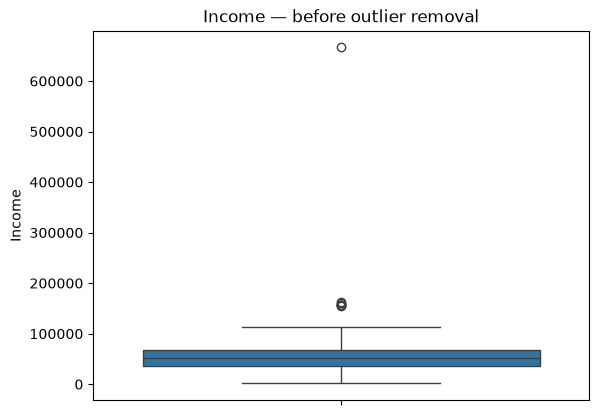

In [41]:
sns.boxplot(data=data, y='Income')
plt.title("Income — before outlier removal")
plt.show()

In [42]:
# One extreme outlier dwarfs the rest of the distribution — drop it by value
# rather than by a hardcoded index, so this still works if upstream rows shift.
outlier_idx = data[data.Income == data.Income.max()].index
data = data.drop(outlier_idx)

## Children

In [43]:
data['Num_Children'] = data.Kidhome + data.Teenhome
data = data.drop(columns=['Kidhome', 'Teenhome'])

In [44]:
data['Has_child'] = data.Num_Children > 0
data.Has_child.value_counts()

Has_child
True     1580
False     632
Name: count, dtype: int64

## Customer tenure

In [45]:
# Convert enrollment date into a single "days since enrollment" feature,
# anchored to a fixed baseline date (just after the dataset's collection window).
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], dayfirst=True, format='%d-%m-%Y')
baseline_date = pd.to_datetime('2014-07-01')
data['Customer_Tenure_in_Days'] = (baseline_date - data['Dt_Customer']).dt.days
data = data.drop(columns=['Dt_Customer'])

## Spend columns

In [46]:
data = data.rename(columns={
    'MntWines': 'Wines',
    'MntFruits': 'Fruits',
    'MntMeatProducts': 'Meat',
    'MntFishProducts': 'Fish',
    'MntSweetProducts': 'Sweets',
    'MntGoldProds': 'Gold',
})

In [47]:
data['total_spend'] = data['Wines'] + data['Fruits'] + data['Meat'] + data['Fish'] + data['Sweets'] + data['Gold']

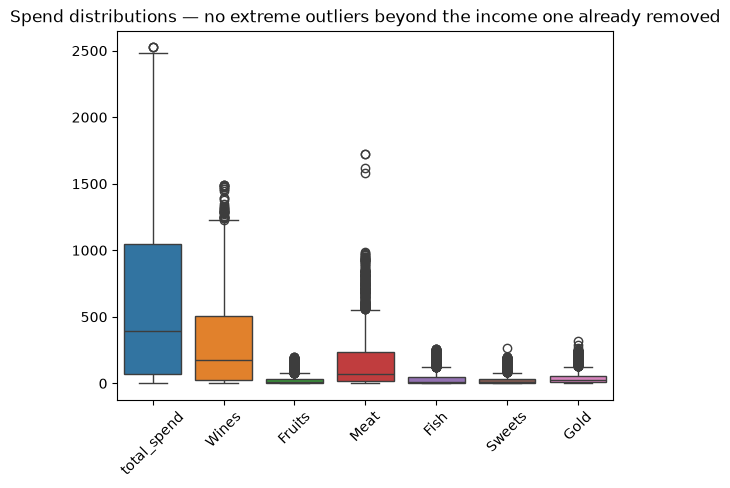

In [48]:
cols = ['total_spend', 'Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold']
sns.boxplot(data=data[cols])
plt.xticks(rotation=45)
plt.title("Spend distributions — no extreme outliers beyond the income one already removed")
plt.show()

## Purchase channel columns

In [49]:
data = data.rename(columns={
    'NumDealsPurchases': 'Deals',
    'NumWebPurchases': 'Web',
    'NumCatalogPurchases': 'Catalogue',
    'NumStorePurchases': 'Store',
    'NumWebVisitsMonth': 'WebVisits',
})

## Campaign response columns

In [50]:
data.nunique()

Year_Birth                   56
Education                     3
Marital_Status                3
Income                     1970
Recency                     100
Wines                       775
Fruits                      158
Meat                        553
Fish                        182
Sweets                      176
Gold                        212
Deals                        15
Web                          15
Catalogue                    14
Store                        14
WebVisits                    16
AcceptedCmp3                  2
AcceptedCmp4                  2
AcceptedCmp5                  2
AcceptedCmp1                  2
AcceptedCmp2                  2
Complain                      2
Z_CostContact                 1
Z_Revenue                     1
Response                      2
age                          56
Num_Children                  4
Has_child                     2
Customer_Tenure_in_Days     662
total_spend                1047
dtype: int64

In [51]:
# Z_Revenue / Z_CostContact are Kaggle-provided constants (same value for every
# row) used for a profit calc that isn't part of this analysis — safe to drop later.
data.Z_Revenue.unique(), data.Z_CostContact.unique()

(array([11]), array([3]))

In [52]:
data.AcceptedCmp1.unique()

array([0, 1])

Quick look at how rare each individual campaign acceptance and the final response are, before consolidating them.

In [53]:
n = data.shape[0]
acceptance_rates = {
    'AcceptedCmp1': data['AcceptedCmp1'].sum() / n,
    'AcceptedCmp2': data['AcceptedCmp2'].sum() / n,
    'AcceptedCmp3': data['AcceptedCmp3'].sum() / n,
    'AcceptedCmp4': data['AcceptedCmp4'].sum() / n,
    'AcceptedCmp5': data['AcceptedCmp5'].sum() / n,
    'Response':     data['Response'].sum() / n,
}
acceptance_rates

{'AcceptedCmp1': np.float64(0.06419529837251356),
 'AcceptedCmp2': np.float64(0.013562386980108499),
 'AcceptedCmp3': np.float64(0.07368896925858952),
 'AcceptedCmp4': np.float64(0.07414104882459313),
 'AcceptedCmp5': np.float64(0.07278481012658228),
 'Response': np.float64(0.15054249547920434)}

Collapse the five historical campaign flags into a single count — `Num_Camp_Success` — used later as the 'past campaign success' CRM feature.

In [54]:
data['Num_Camp_Success'] = data[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].sum(axis=1)
data = data.drop(columns=['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5'])

In [55]:
data = data.drop(columns=['Z_Revenue', 'Z_CostContact'])

## Final formatting & export

In [56]:
data.dtypes

Year_Birth                   int64
Education                      str
Marital_Status                 str
Income                     float64
Recency                      int64
Wines                        int64
Fruits                       int64
Meat                         int64
Fish                         int64
Sweets                       int64
Gold                         int64
Deals                        int64
Web                          int64
Catalogue                    int64
Store                        int64
WebVisits                    int64
Complain                     int64
Response                     int64
age                          int64
Num_Children                 int64
Has_child                     bool
Customer_Tenure_in_Days      int64
total_spend                  int64
Num_Camp_Success             int64
dtype: object

In [57]:
data.columns = data.columns.map(lambda x: x.lower())

In [58]:
data.to_csv("../data/clean/marketing_campaign.csv", index=False, encoding="utf-8", sep=";")
data.shape

(2212, 24)